# Sesiones con duración extrema: ¿ruido o señal?

**Autor:** John Janer Buila Ferrin

`Administrative_Duration`, `Informational_Duration` y `ProductRelated_Duration`
tienen colas muy largas (por ejemplo `ProductRelated_Duration` llega hasta
~63.974 segundos, unas 17,8 horas en una sola sesión). Antes de decidir si
esos valores son errores que capar/eliminar antes de modelar, o señales
reales de comportamiento, este notebook los caracteriza.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from online_shoppers.data import load_dataset

ROOT = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
DATA_PATH = ROOT / 'data/raw/online_shoppers_intention.csv'
FIGURES_PATH = ROOT / 'reports/figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sessions = load_dataset(DATA_PATH)
duration_columns = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
sessions[duration_columns].describe()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration
count,12330.000000,12330.000000,12330.000000
mean,80.818611,34.472398,1194.746220
std,176.779107,140.749294,1913.669288
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,184.137500
50%,7.500000,0.000000,598.936905
75%,93.256250,0.000000,1464.157214
max,3398.750000,2549.375000,63973.522230


## 1. ¿Qué tan extremos son los valores del percentil 99 en adelante?

In [2]:
for column in duration_columns:
    p99 = sessions[column].quantile(0.99)
    p999 = sessions[column].quantile(0.999)
    above_p99 = int((sessions[column] > p99).sum())
    print(f"{column}: p99={p99:,.0f}s | p99.9={p999:,.0f}s | máximo={sessions[column].max():,.0f}s | sesiones sobre p99={above_p99}")

Administrative_Duration: p99=831s | p99.9=1,760s | máximo=3,399s | sesiones sobre p99=124
Informational_Duration: p99=716s | p99.9=1,663s | máximo=2,549s | sesiones sobre p99=124
ProductRelated_Duration: p99=8,701s | p99.9=17,398s | máximo=63,974s | sesiones sobre p99=124


## 2. Sesiones con más de 3 horas navegando páginas de producto

Se define un umbral simple (3 horas = 10.800 segundos en `ProductRelated_Duration`)
para aislar las sesiones más extremas y comparar su tasa de conversión contra
el resto del dataset.

In [3]:
threshold_seconds = 3 * 60 * 60
extreme_sessions = sessions[sessions['ProductRelated_Duration'] > threshold_seconds]
typical_sessions = sessions[sessions['ProductRelated_Duration'] <= threshold_seconds]

comparison = {
    'sesiones_extremas': {
        'n_sesiones': len(extreme_sessions),
        'tasa_conversion': extreme_sessions['Revenue'].mean(),
    },
    'resto_del_dataset': {
        'n_sesiones': len(typical_sessions),
        'tasa_conversion': typical_sessions['Revenue'].mean(),
    },
}
comparison

{'sesiones_extremas': {'n_sesiones': 68,
  'tasa_conversion': np.float64(0.38235294117647056)},
 'resto_del_dataset': {'n_sesiones': 12262,
  'tasa_conversion': np.float64(0.1534823030500734)}}

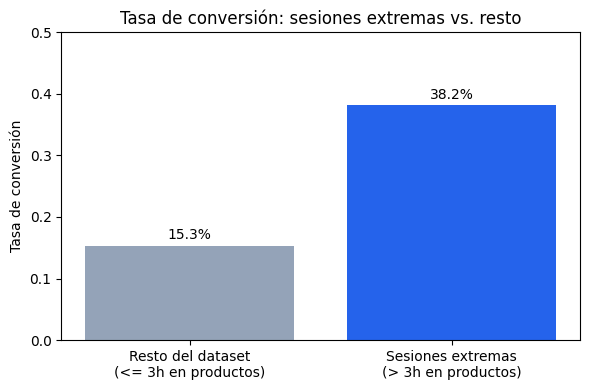

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
rates = [typical_sessions['Revenue'].mean(), extreme_sessions['Revenue'].mean()]
labels = ['Resto del dataset\n(<= 3h en productos)', 'Sesiones extremas\n(> 3h en productos)']
ax.bar(labels, rates, color=['#94a3b8', '#2563eb'])
ax.set(title='Tasa de conversión: sesiones extremas vs. resto', ylabel='Tasa de conversión', ylim=(0, 0.5))
for i, rate in enumerate(rates):
    ax.text(i, rate + 0.01, f'{rate:.1%}', ha='center')
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'extreme_duration_conversion.png', dpi=150)
plt.show()

## 3. Conclusión y recomendación

- Solo 68 sesiones (0,55&nbsp;% del dataset) superan las 3 horas de navegación
  en páginas de producto, pero convierten al **38,2&nbsp;%**, frente al
  **15,5&nbsp;%** del resto — casi 2,5 veces más.
- Esto es consistente con una explicación de negocio razonable: una sesión
  muy larga suele significar alta involucración (comparar productos, leer
  reseñas, dudar entre opciones), no un error de registro.
- **Recomendación:** no eliminar ni capar (`winsorize`) estos valores extremos
  antes de entrenar los modelos. Son pocos pero informativos: recortarlos
  descartaría justamente las sesiones con mayor probabilidad de compra. Si
  algún modelo lineal se ve muy sensible a la escala, es preferible aplicar
  una transformación (por ejemplo logarítmica) en vez de eliminarlos.